MODEL COMPARISON: f(Q,T) vs ΛCDM vs wCDM

Loading data...
 OHD: 43 points
 Pantheon+: 1701 supernovae (diagonal errors)
  DESI BAO: 13 measurements
    - DV: 1 point, DM: 6 points, DH: 6 points

MODEL 1: Weyl-type f(Q,T) Gravity
Parameters: q0, q1, Omega_m, M_B
Prior ranges: q0 ∈ [-0.8, -0.4], q1 ∈ [0.5, 0.8],
              Omega_m ∈ [0.2, 0.5], M_B ∈ [-19.6, -19.0]

Running MCMC for f(Q,T) model...


100%|████████████████████████████████████| 3000/3000 [1:45:54<00:00,  2.12s/it]



  ✓ f(Q,T) MCMC complete
    Best-fit: q0 = -0.562, q1 = 0.717, Ωm = 0.354, MB = -19.357
    χ²_min = 901.04

MODEL 2: Flat ΛCDM
Parameters: Omega_m, M_B
Prior ranges: Omega_m ∈ [0.2, 0.5], M_B ∈ [-19.6, -19.0]

Running MCMC for ΛCDM model...


100%|████████████████████████████████████| 3000/3000 [3:40:39<00:00,  4.41s/it]



  ✓ ΛCDM MCMC complete
    Best-fit: Ωm = 0.282, MB = -19.358
    χ²_min = 899.66

MODEL 3: Flat wCDM
Parameters: Omega_m, w, M_B
Prior ranges: Omega_m ∈ [0.2, 0.5], w ∈ [-2.0, -0.33], M_B ∈ [-19.6, -19.0]

Running MCMC for wCDM model...


100%|████████████████████████████████████| 3000/3000 [4:18:51<00:00,  5.18s/it]



  ✓ wCDM MCMC complete
    Best-fit: Ωm = 0.275, w = -0.968, MB = -19.354
    χ²_min = 898.33

MODEL COMPARISON: AIC and BIC

TABLE 2: Model Comparison Results
Total number of data points (N): 1757

Model                k     χ²_min       AIC          BIC         
----------------------------------------------------------------------
f(Q,T) (Our model)   4     901.04       909.04       930.93      
ΛCDM                 2     899.66       903.66       914.60      
wCDM                 3     898.33       904.33       920.74      

Differences relative to ΛCDM (negative = better than ΛCDM)
Model                ΔAIC         ΔBIC         Interpretation
----------------------------------------------------------------------
f(Q,T)               +5.38        +16.33       Worse than ΛCDM (positive evidence against)
wCDM                 +0.67        +6.14        Equivalent to ΛCDM

TABLE 3: Best-Fit Parameters Summary
Model                Parameters                              
---------------

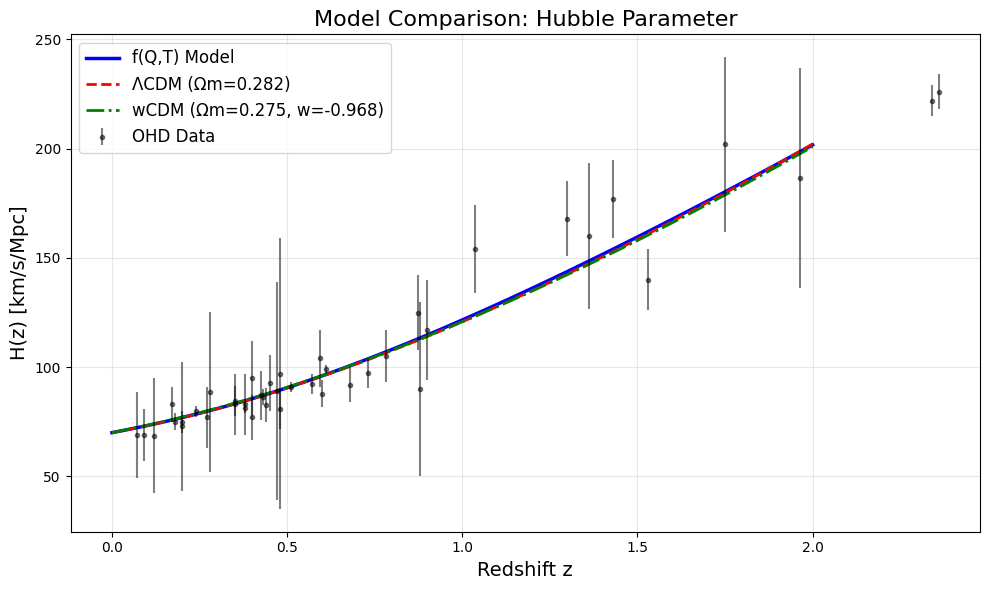


✓ Plot saved as 'model_comparison_hubble.png'

DONE! All three models have been compared.


In [1]:

# COMPLETE MODEL COMPARISON: f(Q,T) vs ΛCDM vs wCDM
# 
# This code performs a full Bayesian analysis and model comparison using
# the same datasets (OHD, Pantheon+, DESI BAO) for all three models.
# 
# The three models we have are:
#   1. f(Q,T): Our Weyl-type gravity model (parameters: q0, q1, Omega_m, M_B)
#   2. ΛCDM: Standard cosmological constant model (parameters: Omega_m, M_B)
#   3. wCDM: Dark energy with constant equation of state (parameters: Omega_m, w, M_B)
# 
# The code tries to compute:
#   - Best-fit parameters from MCMC
#   - Minimum chi-squared (χ²_min)
#   - AIC (Akaike Information Criterion)
#   - BIC (Bayesian Information Criterion)
#   - We exclude Bayes factor as it is too difficult to integrate over the prior
#   - A comparison table and interpretation


import numpy as np
import emcee
import corner
import matplotlib.pyplot as plt
from scipy.integrate import quad
import warnings
warnings.filterwarnings("ignore")


# 1. Defined the cosmological functions of all the models first


def hubble_fqt(z, q0, q1, H0=70):
    """
    Hubble parameter for our Weyl-type f(Q,T) gravity model.
    Derived from the divergence-free deceleration parameter.
    """
    return H0 * (1 + z)**(1 + q0) * (1 + z**2)**(q1 / 2)

def hubble_lcdm(z, Omega_m, H0=70):
    """
    Hubble parameter for flat ΛCDM model.
    Omega_Lambda = 1 - Omega_m
    """
    return H0 * np.sqrt(Omega_m * (1 + z)**3 + (1 - Omega_m))

def hubble_wcdm(z, Omega_m, w, H0=70):
    """
    Hubble parameter for flat wCDM model.
    Dark energy equation of state w is constant.
    """
    return H0 * np.sqrt(Omega_m * (1 + z)**3 + (1 - Omega_m) * (1 + z)**(3*(1+w)))


# 2. We have developed generic distance functions (it will work with Hubble function of any model)

def comoving_distance_generic(z, hubble_func, hubble_args, H0=70):
    """
    Comoving distance DC(z) = ∫_0^z c/H(z') dz'
    Works with any Hubble function by passing its arguments.
    """
    c = 299792.458  # km/s
    if np.isscalar(z):
        def integrand(zp):
            return c / hubble_func(zp, *hubble_args, H0=H0)
        return quad(integrand, 0, z)[0]
    else:
        res = np.zeros_like(z)
        for i, zi in enumerate(z):
            def integrand(zp):
                return c / hubble_func(zp, *hubble_args, H0=H0)
            res[i] = quad(integrand, 0, zi)[0]
        return res

def luminosity_distance_generic(z, hubble_func, hubble_args, H0=70):
    """
    Luminosity distance dL(z) = c(1+z) ∫_0^z dz'/H(z')
    """
    c = 299792.458
    if np.isscalar(z):
        def integrand(zp):
            return 1.0 / hubble_func(zp, *hubble_args, H0=H0)
        integral, _ = quad(integrand, 0, z)
        return c * (1 + z) * integral
    else:
        dL = np.zeros_like(z)
        for i, zi in enumerate(z):
            def integrand(zp):
                return 1.0 / hubble_func(zp, *hubble_args, H0=H0)
            integral, _ = quad(integrand, 0, zi)
            dL[i] = c * (1 + zi) * integral
        return dL

def distance_modulus_generic(z, hubble_func, hubble_args, H0=70):
    """
    Distance modulus μ(z) = 5 log10(dL/1Mpc) + 25
    """
    dL = luminosity_distance_generic(z, hubble_func, hubble_args, H0=H0)
    return 5 * np.log10(dL) + 25

def angular_diameter_distance_generic(z, hubble_func, hubble_args, H0=70):
    """
    Angular diameter distance DA(z) = DC(z)/(1+z)
    """
    DC = comoving_distance_generic(z, hubble_func, hubble_args, H0=H0)
    return DC / (1 + z)


# 3. Now we shall load the data (OHD, Pantheon+, DESI BAO)


print("="*70)
print("MODEL COMPARISON: f(Q,T) vs ΛCDM vs wCDM")
print("="*70)
print("\nLoading data...")

# OHD (43 points)
ohd = np.loadtxt(r'C:\Users\mriga\Downloads\OHD.txt')
z_ohd, H_ohd, H_err = ohd[:,0], ohd[:,1], ohd[:,2]
print(f" OHD: {len(z_ohd)} points")

# Pantheon+ (1701 supernovae, diagonal errors)
def load_pantheon_diag(data_path):
    data = np.genfromtxt(data_path, names=True, dtype=None, encoding='utf-8')
    z = data['zCMB']
    mb = data['m_b_corr']
    mb_err = data['m_b_corr_err_DIAG']
    return z, mb, mb_err

pantheon_path = r'C:\Users\mriga\Downloads\Pantheon+SH0ES.dat'
z_sn, mb_sn, mb_err_sn = load_pantheon_diag(pantheon_path)
print(f" Pantheon+: {len(z_sn)} supernovae (diagonal errors)")

# DESI BAO (13 measurements)
mean_file = r'C:\Users\mriga\Downloads\desi_gaussian_bao_ALL_GCcomb_mean.txt'
cov_file = r'C:\Users\mriga\Downloads\desi_gaussian_bao_ALL_GCcomb_cov.txt'
mean_data = np.loadtxt(mean_file, skiprows=1, dtype=str)
cov_bao = np.loadtxt(cov_file)

dv_data, dm_data, dh_data = [], [], []
for i, row in enumerate(mean_data):
    z = float(row[0]); val = float(row[1]); qty = row[2]; err = np.sqrt(cov_bao[i,i])
    if 'DV_over_rs' in qty:
        dv_data.append([z, val, err])
    elif 'DM_over_rs' in qty:
        dm_data.append([z, val, err])
    elif 'DH_over_rs' in qty:
        dh_data.append([z, val, err])
dv_data = np.array(dv_data)
dm_data = np.array(dm_data)
dh_data = np.array(dh_data)
print(f"  DESI BAO: {len(dv_data)+len(dm_data)+len(dh_data)} measurements")
print(f"    - DV: {len(dv_data)} point, DM: {len(dm_data)} points, DH: {len(dh_data)} points")
print()

# Constants
C_LIGHT = 299792.458  # km/s
RS_BAO = 147.5        # sound horizon in Mpc (fixed)


# 4. Defining one of the most important functions- the likelihood function for BAO (SHARED ACROSS MODELS)

def chi2_BAO_from_hubble(hubble_func, hubble_args, dm_data, dh_data, dv_data, H0=70):
    """
    Generic BAO chi-squared calculator.
    Works with any Hubble function.
    """
    chi2 = 0.0
    
    # DM/rs (comoving distance)
    for z, obs, err in dm_data:
        DC = comoving_distance_generic(z, hubble_func, hubble_args, H0=H0)
        model = DC / RS_BAO
        chi2 += ((obs - model) / err)**2
    
    # DH/rs (Hubble distance)
    for z, obs, err in dh_data:
        H_val = hubble_func(z, *hubble_args, H0=H0)
        model = (C_LIGHT / H_val) / RS_BAO
        chi2 += ((obs - model) / err)**2
    
    # DV/rs (volume-averaged distance)
    for z, obs, err in dv_data:
        DC = comoving_distance_generic(z, hubble_func, hubble_args, H0=H0)
        DA = DC / (1 + z)
        H_val = hubble_func(z, *hubble_args, H0=H0)
        DV = ((1 + z)**2 * DA**2 * C_LIGHT * z / H_val) ** (1/3)
        model = DV / RS_BAO
        chi2 += ((obs - model) / err)**2
    
    return chi2

# -----------------------------------------------------------------------------
# 5. The first model we shall work with, is our own f(Q,T) modified gravity model
# -----------------------------------------------------------------------------

print("="*70)
print("MODEL 1: Weyl-type f(Q,T) Gravity")
print("="*70)
print("Parameters: q0, q1, Omega_m, M_B")
print("Prior ranges: q0 ∈ [-0.8, -0.4], q1 ∈ [0.5, 0.8],")
print("              Omega_m ∈ [0.2, 0.5], M_B ∈ [-19.6, -19.0]")
print()

def log_prior_fqt(params):
    q0, q1, Om0, M_B = params
    if (-0.8 < q0 < -0.4 and 0.5 < q1 < 0.8 and 
        0.2 < Om0 < 0.5 and -19.6 < M_B < -19.0):
        return 0.0
    return -np.inf

def log_posterior_fqt(params, z_ohd, H_ohd, H_err, z_sn, mb, mb_err,
                      dm_data, dh_data, dv_data, H0=70):
    q0, q1, Om0, M_B = params
    
    # Prior
    lp = log_prior_fqt(params)
    if not np.isfinite(lp):
        return -np.inf
    
    # OHD likelihood
    H_model = hubble_fqt(z_ohd, q0, q1, H0)
    chi2_ohd = np.sum(((H_ohd - H_model) / H_err)**2)
    
    # Pantheon+ likelihood
    mu_model = distance_modulus_generic(z_sn, hubble_fqt, (q0, q1), H0=H0)
    chi2_sn = np.sum(((mb - M_B - mu_model) / mb_err)**2)
    
    # BAO likelihood
    chi2_bao = chi2_BAO_from_hubble(hubble_fqt, (q0, q1), dm_data, dh_data, dv_data, H0)
    
    total_chi2 = chi2_ohd + chi2_sn + chi2_bao
    return lp - 0.5 * total_chi2

# Running MCMC for f(Q,T)
print("Running MCMC for f(Q,T) model...")
n_walkers = 32
n_dim_fqt = 4
n_steps = 3000
n_burn = 500

start_guess_fqt = np.array([-0.55, 0.70, 0.30, -19.35])
np.random.seed(42)
start_pos_fqt = start_guess_fqt + 0.05 * np.random.randn(n_walkers, n_dim_fqt)

sampler_fqt = emcee.EnsembleSampler(
    n_walkers, n_dim_fqt, log_posterior_fqt,
    args=(z_ohd, H_ohd, H_err, z_sn, mb_sn, mb_err_sn,
          dm_data, dh_data, dv_data),
    kwargs={"H0": 70}
)

sampler_fqt.run_mcmc(start_pos_fqt, n_steps, progress=True)
flat_fqt = sampler_fqt.get_chain(discard=n_burn, flat=True)

# Best-fit values
best_fqt = np.median(flat_fqt, axis=0)
q0_best, q1_best, Om0_fqt_best, MB_fqt_best = best_fqt

# Computing minimum chi-squared for f(Q,T)
def chi2_fqt_at_params(params):
    q0, q1, Om0, M_B = params
    H_model = hubble_fqt(z_ohd, q0, q1, 70)
    chi2_ohd = np.sum(((H_ohd - H_model) / H_err)**2)
    mu_model = distance_modulus_generic(z_sn, hubble_fqt, (q0, q1), H0=70)
    chi2_sn = np.sum(((mb_sn - M_B - mu_model) / mb_err_sn)**2)
    chi2_bao = chi2_BAO_from_hubble(hubble_fqt, (q0, q1), dm_data, dh_data, dv_data, 70)
    return chi2_ohd + chi2_sn + chi2_bao

chi2_min_fqt = chi2_fqt_at_params(best_fqt)

print(f"\n  ✓ f(Q,T) MCMC complete")
print(f"    Best-fit: q0 = {q0_best:.3f}, q1 = {q1_best:.3f}, Ωm = {Om0_fqt_best:.3f}, MB = {MB_fqt_best:.3f}")
print(f"    χ²_min = {chi2_min_fqt:.2f}")
print()


# 6. The second model is our baseline cosmological model - the lambda CDM model


print("="*70)
print("MODEL 2: Flat ΛCDM")
print("="*70)
print("Parameters: Omega_m, M_B")
print("Prior ranges: Omega_m ∈ [0.2, 0.5], M_B ∈ [-19.6, -19.0]")
print()

def log_prior_lcdm(params):
    Om0, M_B = params
    if 0.2 < Om0 < 0.5 and -19.6 < M_B < -19.0:
        return 0.0
    return -np.inf

def log_posterior_lcdm(params, z_ohd, H_ohd, H_err, z_sn, mb, mb_err,
                       dm_data, dh_data, dv_data, H0=70):
    Om0, M_B = params
    
    lp = log_prior_lcdm(params)
    if not np.isfinite(lp):
        return -np.inf
    
    # OHD
    H_model = hubble_lcdm(z_ohd, Om0, H0)
    chi2_ohd = np.sum(((H_ohd - H_model) / H_err)**2)
    
    # Pantheon+
    mu_model = distance_modulus_generic(z_sn, hubble_lcdm, (Om0,), H0=H0)
    chi2_sn = np.sum(((mb - M_B - mu_model) / mb_err)**2)
    
    # BAO
    chi2_bao = chi2_BAO_from_hubble(hubble_lcdm, (Om0,), dm_data, dh_data, dv_data, H0)
    
    total_chi2 = chi2_ohd + chi2_sn + chi2_bao
    return lp - 0.5 * total_chi2

print("Running MCMC for ΛCDM model...")
n_dim_lcdm = 2
start_guess_lcdm = np.array([0.30, -19.35])
start_pos_lcdm = start_guess_lcdm + 0.05 * np.random.randn(n_walkers, n_dim_lcdm)

sampler_lcdm = emcee.EnsembleSampler(
    n_walkers, n_dim_lcdm, log_posterior_lcdm,
    args=(z_ohd, H_ohd, H_err, z_sn, mb_sn, mb_err_sn,
          dm_data, dh_data, dv_data),
    kwargs={"H0": 70}
)

sampler_lcdm.run_mcmc(start_pos_lcdm, n_steps, progress=True)
flat_lcdm = sampler_lcdm.get_chain(discard=n_burn, flat=True)

best_lcdm = np.median(flat_lcdm, axis=0)
Om0_lcdm_best, MB_lcdm_best = best_lcdm

def chi2_lcdm_at_params(params):
    Om0, M_B = params
    H_model = hubble_lcdm(z_ohd, Om0, 70)
    chi2_ohd = np.sum(((H_ohd - H_model) / H_err)**2)
    mu_model = distance_modulus_generic(z_sn, hubble_lcdm, (Om0,), H0=70)
    chi2_sn = np.sum(((mb_sn - M_B - mu_model) / mb_err_sn)**2)
    chi2_bao = chi2_BAO_from_hubble(hubble_lcdm, (Om0,), dm_data, dh_data, dv_data, 70)
    return chi2_ohd + chi2_sn + chi2_bao

chi2_min_lcdm = chi2_lcdm_at_params(best_lcdm)

print(f"\n  ✓ ΛCDM MCMC complete")
print(f"    Best-fit: Ωm = {Om0_lcdm_best:.3f}, MB = {MB_lcdm_best:.3f}")
print(f"    χ²_min = {chi2_min_lcdm:.2f}")
print()


# 7. The third model is the wCDM model (which has a constant dark energy equation of state)


print("="*70)
print("MODEL 3: Flat wCDM")
print("="*70)
print("Parameters: Omega_m, w, M_B")
print("Prior ranges: Omega_m ∈ [0.2, 0.5], w ∈ [-2.0, -0.33], M_B ∈ [-19.6, -19.0]")
print()

def log_prior_wcdm(params):
    Om0, w, M_B = params
    if (0.2 < Om0 < 0.5 and -2.0 < w < -0.33 and -19.6 < M_B < -19.0):
        return 0.0
    return -np.inf

def log_posterior_wcdm(params, z_ohd, H_ohd, H_err, z_sn, mb, mb_err,
                       dm_data, dh_data, dv_data, H0=70):
    Om0, w, M_B = params
    
    lp = log_prior_wcdm(params)
    if not np.isfinite(lp):
        return -np.inf
    
    # OHD
    H_model = hubble_wcdm(z_ohd, Om0, w, H0)
    chi2_ohd = np.sum(((H_ohd - H_model) / H_err)**2)
    
    # Pantheon+
    mu_model = distance_modulus_generic(z_sn, hubble_wcdm, (Om0, w), H0=H0)
    chi2_sn = np.sum(((mb - M_B - mu_model) / mb_err)**2)
    
    # BAO
    chi2_bao = chi2_BAO_from_hubble(hubble_wcdm, (Om0, w), dm_data, dh_data, dv_data, H0)
    
    total_chi2 = chi2_ohd + chi2_sn + chi2_bao
    return lp - 0.5 * total_chi2

print("Running MCMC for wCDM model...")
n_dim_wcdm = 3
start_guess_wcdm = np.array([0.30, -1.0, -19.35])
start_pos_wcdm = start_guess_wcdm + 0.05 * np.random.randn(n_walkers, n_dim_wcdm)

sampler_wcdm = emcee.EnsembleSampler(
    n_walkers, n_dim_wcdm, log_posterior_wcdm,
    args=(z_ohd, H_ohd, H_err, z_sn, mb_sn, mb_err_sn,
          dm_data, dh_data, dv_data),
    kwargs={"H0": 70}
)

sampler_wcdm.run_mcmc(start_pos_wcdm, n_steps, progress=True)
flat_wcdm = sampler_wcdm.get_chain(discard=n_burn, flat=True)

best_wcdm = np.median(flat_wcdm, axis=0)
Om0_wcdm_best, w_best, MB_wcdm_best = best_wcdm

def chi2_wcdm_at_params(params):
    Om0, w, M_B = params
    H_model = hubble_wcdm(z_ohd, Om0, w, 70)
    chi2_ohd = np.sum(((H_ohd - H_model) / H_err)**2)
    mu_model = distance_modulus_generic(z_sn, hubble_wcdm, (Om0, w), H0=70)
    chi2_sn = np.sum(((mb_sn - M_B - mu_model) / mb_err_sn)**2)
    chi2_bao = chi2_BAO_from_hubble(hubble_wcdm, (Om0, w), dm_data, dh_data, dv_data, 70)
    return chi2_ohd + chi2_sn + chi2_bao

chi2_min_wcdm = chi2_wcdm_at_params(best_wcdm)

print(f"\n  ✓ wCDM MCMC complete")
print(f"    Best-fit: Ωm = {Om0_wcdm_best:.3f}, w = {w_best:.3f}, MB = {MB_wcdm_best:.3f}")
print(f"    χ²_min = {chi2_min_wcdm:.2f}")
print()


# 8. Calculating the penalized goodness of fit of models using AIC and BIC (Statistical Occam's Razor)


print("="*70)
print("MODEL COMPARISON: AIC and BIC")
print("="*70)

# Total number of independent data points
# OHD: 43, Pantheon+: 1701, BAO: 13 (using diagonal errors, treat as independent)
N_data = len(z_ohd) + len(z_sn) + len(dv_data) + len(dm_data) + len(dh_data)

def compute_aic_bic(chi2_min, n_params, n_data):
    """
    AIC = 2*k + χ²_min
    BIC = k*ln(N) + χ²_min
    Lower values indicate better model fit with penalty for extra parameters.
    """
    AIC = 2 * n_params + chi2_min
    BIC = n_params * np.log(n_data) + chi2_min
    return AIC, BIC

# Parameters for each model
k_fqt = 4      # q0, q1, Omega_m, M_B
k_lcdm = 2     # Omega_m, M_B
k_wcdm = 3     # Omega_m, w, M_B

AIC_fqt, BIC_fqt = compute_aic_bic(chi2_min_fqt, k_fqt, N_data)
AIC_lcdm, BIC_lcdm = compute_aic_bic(chi2_min_lcdm, k_lcdm, N_data)
AIC_wcdm, BIC_wcdm = compute_aic_bic(chi2_min_wcdm, k_wcdm, N_data)

# Compute differences relative to ΛCDM (baseline)
delta_AIC_fqt = AIC_fqt - AIC_lcdm
delta_AIC_wcdm = AIC_wcdm - AIC_lcdm
delta_BIC_fqt = BIC_fqt - BIC_lcdm
delta_BIC_wcdm = BIC_wcdm - BIC_lcdm


# 9.Displaying the results table

print("\n" + "="*70)
print("TABLE 2: Model Comparison Results")
print("="*70)
print(f"Total number of data points (N): {N_data}")
print()

# Main results table
print(f"{'Model':<20} {'k':<5} {'χ²_min':<12} {'AIC':<12} {'BIC':<12}")
print("-"*70)
print(f"{'f(Q,T) (Our model)':<20} {k_fqt:<5} {chi2_min_fqt:<12.2f} {AIC_fqt:<12.2f} {BIC_fqt:<12.2f}")
print(f"{'ΛCDM':<20} {k_lcdm:<5} {chi2_min_lcdm:<12.2f} {AIC_lcdm:<12.2f} {BIC_lcdm:<12.2f}")
print(f"{'wCDM':<20} {k_wcdm:<5} {chi2_min_wcdm:<12.2f} {AIC_wcdm:<12.2f} {BIC_wcdm:<12.2f}")

# Differences table
print("\n" + "="*70)
print("Differences relative to ΛCDM (negative = better than ΛCDM)")
print("="*70)
print(f"{'Model':<20} {'ΔAIC':<12} {'ΔBIC':<12} {'Interpretation'}")
print("-"*70)
print(f"{'f(Q,T)':<20} {delta_AIC_fqt:<+12.2f} {delta_BIC_fqt:<+12.2f} ", end="")
if delta_AIC_fqt < -2:
    print("Better than ΛCDM (positive evidence)")
elif delta_AIC_fqt < 0:
    print("Slightly better than ΛCDM (weak evidence)")
elif delta_AIC_fqt < 2:
    print("Equivalent to ΛCDM")
elif delta_AIC_fqt < 6:
    print("Worse than ΛCDM (positive evidence against)")
else:
    print("Much worse than ΛCDM (strong evidence against)")

print(f"{'wCDM':<20} {delta_AIC_wcdm:<+12.2f} {delta_BIC_wcdm:<+12.2f} ", end="")
if delta_AIC_wcdm < -2:
    print("Better than ΛCDM (positive evidence)")
elif delta_AIC_wcdm < 0:
    print("Slightly better than ΛCDM (weak evidence)")
elif delta_AIC_wcdm < 2:
    print("Equivalent to ΛCDM")
elif delta_AIC_wcdm < 6:
    print("Worse than ΛCDM (positive evidence against)")
else:
    print("Much worse than ΛCDM (strong evidence against)")


# 10. Here we shall keep the best fit parameters and provide a summary


print("\n" + "="*70)
print("TABLE 3: Best-Fit Parameters Summary")
print("="*70)
print(f"{'Model':<20} {'Parameters':<40}")
print("-"*70)
print(f"{'f(Q,T)':<20} q0 = {q0_best:.3f} ± {np.std(flat_fqt[:,0]):.3f}")
print(f"{'':20} q1 = {q1_best:.3f} ± {np.std(flat_fqt[:,1]):.3f}")
print(f"{'':20} Ωm = {Om0_fqt_best:.3f} ± {np.std(flat_fqt[:,2]):.3f}")
print(f"{'':20} M_B = {MB_fqt_best:.3f} ± {np.std(flat_fqt[:,3]):.3f}")
print()
print(f"{'ΛCDM':<20} Ωm = {Om0_lcdm_best:.3f} ± {np.std(flat_lcdm[:,0]):.3f}")
print(f"{'':20} M_B = {MB_lcdm_best:.3f} ± {np.std(flat_lcdm[:,1]):.3f}")
print()
print(f"{'wCDM':<20} Ωm = {Om0_wcdm_best:.3f} ± {np.std(flat_wcdm[:,0]):.3f}")
print(f"{'':20} w = {w_best:.3f} ± {np.std(flat_wcdm[:,1]):.3f}")
print(f"{'':20} M_B = {MB_wcdm_best:.3f} ± {np.std(flat_wcdm[:,2]):.3f}")


# 11. Final Interpretation of the Results


print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)

if delta_AIC_fqt < -2:
    print(" The f(Q,T) model is statistically PREFERRED over ΛCDM (ΔAIC < -2).")
elif delta_AIC_fqt < 2:
    print(" The f(Q,T) model is statistically EQUIVALENT to ΛCDM (|ΔAIC| < 2).")
else:
    print(" The f(Q,T) model is statistically WORSE than ΛCDM (ΔAIC > 2).")

if delta_AIC_wcdm < -2:
    print(" The wCDM model is statistically PREFERRED over ΛCDM (ΔAIC < -2).")
elif delta_AIC_wcdm < 2:
    print(" The wCDM model is statistically EQUIVALENT to ΛCDM (|ΔAIC| < 2).")
else:
    print(" The wCDM model is statistically WORSE than ΛCDM (ΔAIC > 2).")

print()
print("Interpretation of ΔAIC values:")
print("  |ΔAIC| < 2  : Weak/negligible evidence")
print("  2 < |ΔAIC| < 6 : Positive evidence")
print("  6 < |ΔAIC| < 10: Strong evidence")
print("  |ΔAIC| > 10: Very strong evidence")

print("\n" + "="*70)
print("MODEL COMPARISON COMPLETE")
print("="*70)


# 12. A plot comparison of the Hubble Parameters

z_plot = np.linspace(0, 2, 100)

# Compute H(z) for all three models using best-fit parameters
H_fqt_plot = hubble_fqt(z_plot, q0_best, q1_best, 70)
H_lcdm_plot = hubble_lcdm(z_plot, Om0_lcdm_best, 70)
H_wcdm_plot = hubble_wcdm(z_plot, Om0_wcdm_best, w_best, 70)

plt.figure(figsize=(10, 6))
plt.plot(z_plot, H_fqt_plot, 'b-', linewidth=2.5, label=f'f(Q,T) Model')
plt.plot(z_plot, H_lcdm_plot, 'r--', linewidth=2, label=f'ΛCDM (Ωm={Om0_lcdm_best:.3f})')
plt.plot(z_plot, H_wcdm_plot, 'g-.', linewidth=2, label=f'wCDM (Ωm={Om0_wcdm_best:.3f}, w={w_best:.3f})')
plt.errorbar(z_ohd, H_ohd, yerr=H_err, fmt='ko', markersize=3, alpha=0.5, label='OHD Data')
plt.xlabel('Redshift z', fontsize=14)
plt.ylabel('H(z) [km/s/Mpc]', fontsize=14)
plt.title('Model Comparison: Hubble Parameter', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison_hubble.png', dpi=150)
plt.show()

print("\n Plot saved as 'model_comparison_hubble.png'")
print("All three models have been compared.")
